Thermal diffusivity = 7.692307692307692e-06


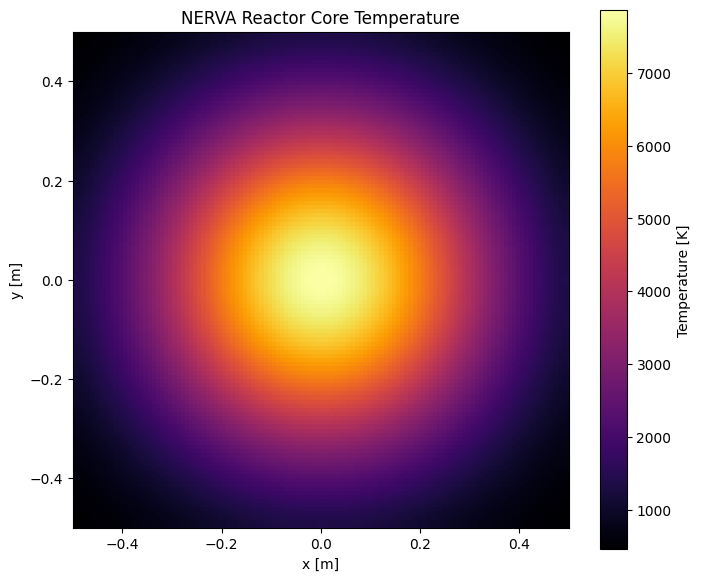

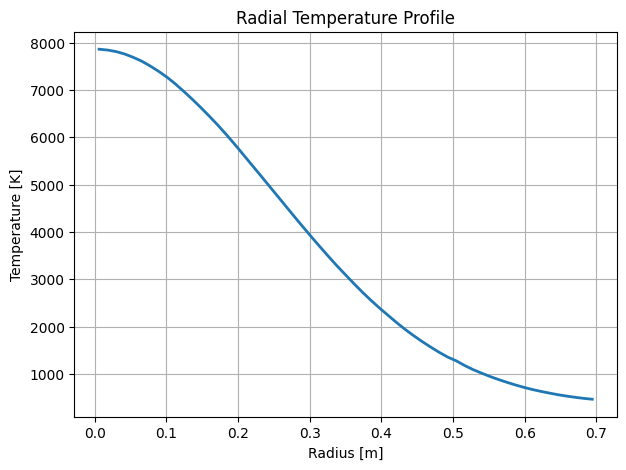

Generating MP4 animation...
MP4 file saved:
NERVA_Core_Temperature.mp4

========== NTR RESULTS ==========
Maximum Temperature : 7861.5 K
Average Temperature : 2934.2 K
Minimum Temperature : 454.4 K


In [1]:
# ==========================================================
# Nuclear Thermal Rocket (NERVA)
# Realistic 2D Core Temperature Simulation
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ==========================================================
# GEOMETRY
# ==========================================================

Nx = 120
Ny = 120

Lx = 1.0
Ly = 1.0

dx = Lx/Nx
dy = Ly/Ny

# ==========================================================
# MATERIAL PROPERTIES
# UC-ZrC Fuel Approximation
# ==========================================================

rho = 13000.0          # kg/m3
cp  = 300.0            # J/kg/K
k   = 30.0             # W/m/K

alpha = k/(rho*cp)

print("Thermal diffusivity =",alpha)

# ==========================================================
# INITIAL CONDITIONS
# ==========================================================

Tinlet = 300.0

T = np.ones((Ny,Nx))*Tinlet

# ==========================================================
# REACTOR POWER
# ==========================================================

core_radius = 0.35

x = np.linspace(-Lx/2,Lx/2,Nx)
y = np.linspace(-Ly/2,Ly/2,Ny)

X,Y = np.meshgrid(x,y)

R = np.sqrt(X**2+Y**2)

# volumetric fission heating

q0 = 4e9

Q = q0*np.exp(-(R/core_radius)**2)

# ==========================================================
# HYDROGEN COOLING
# ==========================================================

T_h2 = 300.0

h_eff = 2.5e5

# ==========================================================
# TIME DISCRETIZATION
# ==========================================================

dt = 0.002
steps = 5000

snapshots = []

# ==========================================================
# SOLVER
# ==========================================================

for n in range(steps):

    Tn = T.copy()

    lap = (
        (Tn[1:-1,2:] - 2*Tn[1:-1,1:-1] + Tn[1:-1,:-2])/dx**2
        +
        (Tn[2:,1:-1] - 2*Tn[1:-1,1:-1] + Tn[:-2,1:-1])/dy**2
    )

    conduction = alpha*lap

    fission = Q[1:-1,1:-1]/(rho*cp)

    cooling = (
        h_eff*
        (Tn[1:-1,1:-1]-T_h2)
        /(rho*cp)
    )

    T[1:-1,1:-1] = (
        Tn[1:-1,1:-1]
        +
        dt*
        (
            conduction
            +
            fission
            -
            cooling
        )
    )

    # Reflective boundaries

    T[0,:]  = T[1,:]
    T[-1,:] = T[-2,:]

    T[:,0]  = T[:,1]
    T[:,-1] = T[:,-2]

    if n % 50 == 0:
        snapshots.append(T.copy())

# ==========================================================
# FINAL TEMPERATURE MAP
# ==========================================================

plt.figure(figsize=(8,7))

plt.imshow(
    T,
    origin="lower",
    extent=[x.min(),x.max(),y.min(),y.max()],
    cmap="inferno"
)

plt.colorbar(label="Temperature [K]")

plt.title("NERVA Reactor Core Temperature")
plt.xlabel("x [m]")
plt.ylabel("y [m]")

plt.show()

# ==========================================================
# RADIAL PROFILE
# ==========================================================

rbins = np.linspace(0,0.7,60)

rtemp = []

for i in range(len(rbins)-1):

    mask = (
        (R>=rbins[i]) &
        (R<rbins[i+1])
    )

    rtemp.append(np.mean(T[mask]))

rmid = 0.5*(rbins[:-1]+rbins[1:])

plt.figure(figsize=(7,5))

plt.plot(rmid,rtemp,lw=2)

plt.grid()

plt.xlabel("Radius [m]")
plt.ylabel("Temperature [K]")

plt.title("Radial Temperature Profile")

plt.show()

# ==========================================================
# MP4 ANIMATION
# ==========================================================

from matplotlib.animation import FFMpegWriter

print("Generating MP4 animation...")

fig, ax = plt.subplots(figsize=(8,7))

vmin = min(np.min(s) for s in snapshots)
vmax = max(np.max(s) for s in snapshots)

im = ax.imshow(
    snapshots[0],
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
    animated=True
)

cbar = plt.colorbar(im)
cbar.set_label("Temperature [K]")

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")

def update(frame):

    im.set_array(snapshots[frame])

    ax.set_title(
        f"NERVA Reactor Core Heating\n"
        f"Frame {frame+1}/{len(snapshots)}"
    )

    return [im]

ani = FuncAnimation(
    fig,
    update,
    frames=len(snapshots),
    interval=60,
    blit=True
)

# --------------------------------------------------
# Save MP4
# --------------------------------------------------

writer = FFMpegWriter(
    fps=20,
    metadata={"artist": "ChatGPT"},
    bitrate=3000
)

ani.save(
    "NERVA_Core_Temperature.mp4",
    writer=writer,
    dpi=150
)

plt.close()

print("MP4 file saved:")
print("NERVA_Core_Temperature.mp4")
# ==========================================================
# DIAGNOSTICS
# ==========================================================

print()
print("========== NTR RESULTS ==========")
print(f"Maximum Temperature : {T.max():.1f} K")
print(f"Average Temperature : {T.mean():.1f} K")
print(f"Minimum Temperature : {T.min():.1f} K")
print("=================================")